In [3]:
import pandas as pd
import numpy as np

train = pd.read_csv(r"C:\Users\AJMAL AHMED\OneDrive\Desktop\KAGGLE PROJECT\Datasets\fraudTrain.csv")
test = pd.read_csv(r"C:\Users\AJMAL AHMED\OneDrive\Desktop\KAGGLE PROJECT\Datasets\fraudTest.csv")
train.head()
test.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [4]:
df = pd.concat([train,test],ignore_index=True)
print(df.shape)

(1852394, 23)


In [5]:
df['is_fraud'].value_counts()

is_fraud
0    1842743
1       9651
Name: count, dtype: int64

In [6]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1852394 entries, 0 to 1852393
Data columns (total 23 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Unnamed: 0             int64  
 1   trans_date_trans_time  str    
 2   cc_num                 int64  
 3   merchant               str    
 4   category               str    
 5   amt                    float64
 6   first                  str    
 7   last                   str    
 8   gender                 str    
 9   street                 str    
 10  city                   str    
 11  state                  str    
 12  zip                    int64  
 13  lat                    float64
 14  long                   float64
 15  city_pop               int64  
 16  job                    str    
 17  dob                    str    
 18  trans_num              str    
 19  unix_time              int64  
 20  merch_lat              float64
 21  merch_long             float64
 22  is_fraud               int64 

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop(columns=['Unnamed: 0'])

In [10]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [11]:
df['dob'] = pd.to_datetime(df['dob'])

In [12]:
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days // 365

In [13]:
df['hour'] = df['trans_date_trans_time'].dt.hour
df['day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['month'] = df['trans_date_trans_time'].dt.month

In [14]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    lat1,lon1,lat2,lon2 = map(np.radians, [lat1,lon1,lat2,lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 +np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))
df['distance_km'] = haversine(df['lat'],df['long'],df['merch_lat'],df['merch_long'])

In [15]:
df[['age','hour','day_of_week','month','distance_km']].head()

,age,hour,day_of_week,month,distance_km
0,30,0,Tuesday,1,78.597568
1,40,0,Tuesday,1,30.212176
2,56,0,Tuesday,1,108.206083
3,52,0,Tuesday,1,95.673231
4,32,0,Tuesday,1,77.556744


In [16]:
fraud = df[df['is_fraud'] == 1]
legit = df[df['is_fraud'] == 0]
print("Total fraud available: ", len(fraud))
fraud_sample = fraud.sample(n=min(len(fraud),300), random_state=42)
legit_sample = legit.sample(n=25000 - len(fraud_sample), random_state=42)
sample_df = pd.concat([fraud_sample,legit_sample]).sample(frac=1, random_state=42).reset_index(drop=True)
print("Sample shape: ", sample_df.shape)
print(sample_df['is_fraud'].value_counts())

Total fraud available:  9651
Sample shape:  (25000, 27)
is_fraud
0    24700
1      300
Name: count, dtype: int64


In [17]:
import os
os.makedirs("data_clean",exist_ok=True)
sample_df.to_csv("data_clean/fraud_sample_25k.csv",index=False)
print("Saved successfully")

Saved successfully


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

## EDA Summary — Key Findings

1. **Category**: Online/e-commerce categories (shopping_net, misc_net) and grocery_pos show highest fraud rates (~2.8-3.2%), vs <0.4% for low-risk categories.
2. **Time of day**: Fraud spikes dramatically overnight (10 PM-3 AM, up to 6.4%) vs daytime (<0.4%).
3. **Amount**: Fraud transactions are typically much larger (median ~₹350) than legit transactions (median ~₹40-50).
4. **Day of week**: Saturday shows highest fraud rate (~1.65%), lowest on Monday/Tuesday.
5. **Age**: Fraud is disproportionately more common among customers aged 55+.
6. **State**: Alaska and Hawaii show highest fraud rates, though caution advised due to small sample sizes in low-population states.

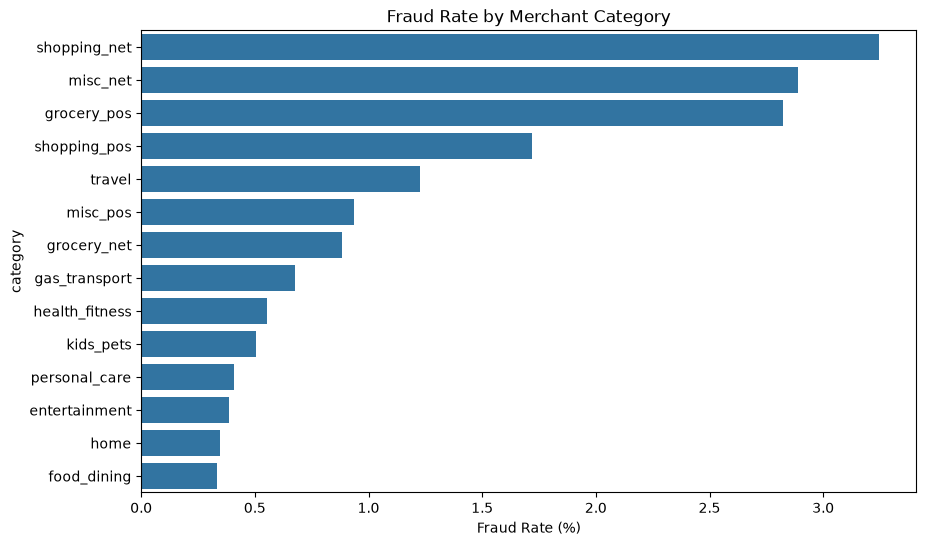

In [19]:
os.makedirs("charts",exist_ok=True)
category_fraud = sample_df.groupby('category')['is_fraud'].mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10,6))
sns.barplot(x=category_fraud.values, y=category_fraud.index)
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Rate by Merchant Category')
plt.savefig("charts/01_fraud_by_category.png", bbox_inches='tight')
plt.show()

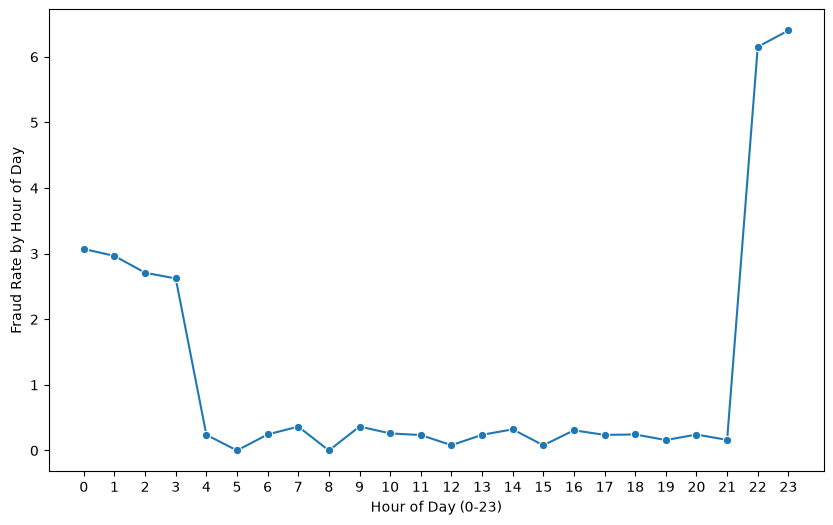

In [20]:
hour_fraud = sample_df.groupby('hour')['is_fraud'].mean() * 100
plt.figure(figsize=(10,6))
sns.lineplot(x=hour_fraud.index, y=hour_fraud.values, marker = 'o')
plt.xlabel("Hour of Day (0-23)")
plt.ylabel("Fraud Rate by Hour of Day")
plt.xticks(range(0,24))
plt.savefig("charts/02_fraud_rate_by_hour.png", bbox_inches='tight')
plt.show()

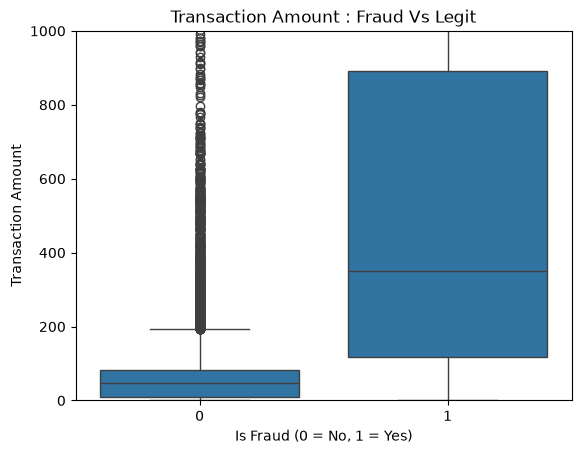

In [21]:
plt.Figure(figsize=(10,6))
sns.boxplot(x='is_fraud', y='amt', data=sample_df)
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transaction Amount")
plt.title("Transaction Amount : Fraud Vs Legit")
plt.ylim(0,1000)
plt.savefig("charts/03_fraud_vs_legit_transaction_amount.png", bbox_inches='tight')
plt.show()


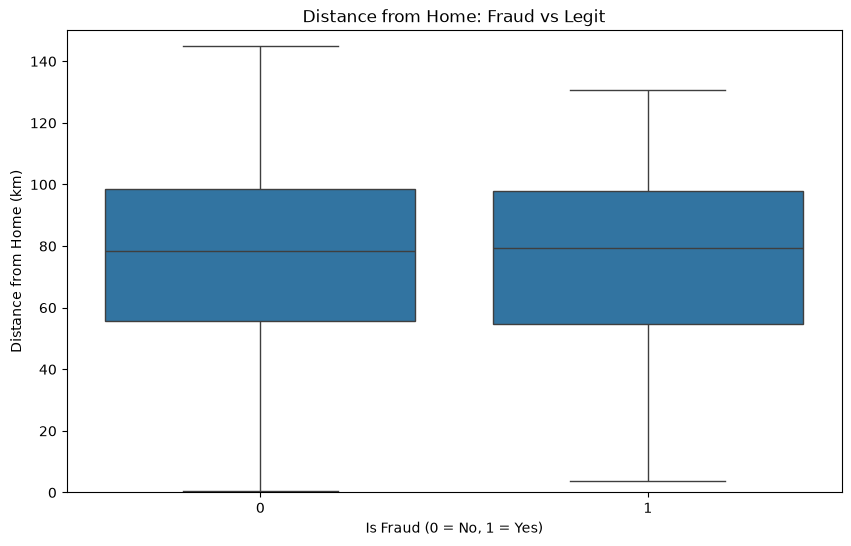

In [22]:
plt.figure(figsize=(10,6))
sns.boxplot(x='is_fraud', y='distance_km', data=sample_df)
plt.xlabel('Is Fraud (0 = No, 1 = Yes)')
plt.ylabel('Distance from Home (km)')
plt.title('Distance from Home: Fraud vs Legit')
plt.ylim(0, 150)
plt.savefig("charts/04_fraud_vs_legit_distance_from_home.png", bbox_inches='tight')
plt.show()

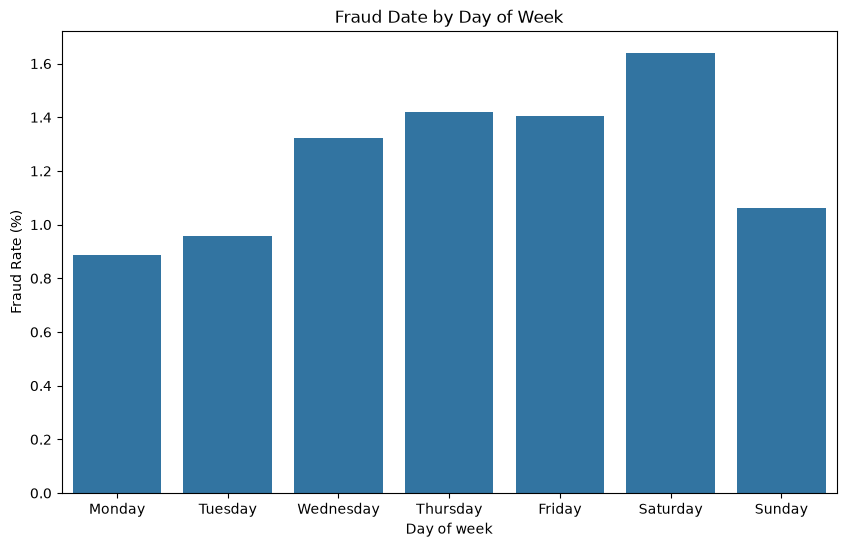

In [23]:
day_fraud = sample_df.groupby('day_of_week')['is_fraud'].mean() * 100
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_fraud = day_fraud.reindex(day_order)
plt.figure(figsize=(10,6))
sns.barplot(x=day_fraud.index, y=day_fraud.values)
plt.xlabel("Day of week")
plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Date by Day of Week")
plt.savefig("charts/05_fraud_rate_by_day.png", bbox_inches='tight')
plt.show()

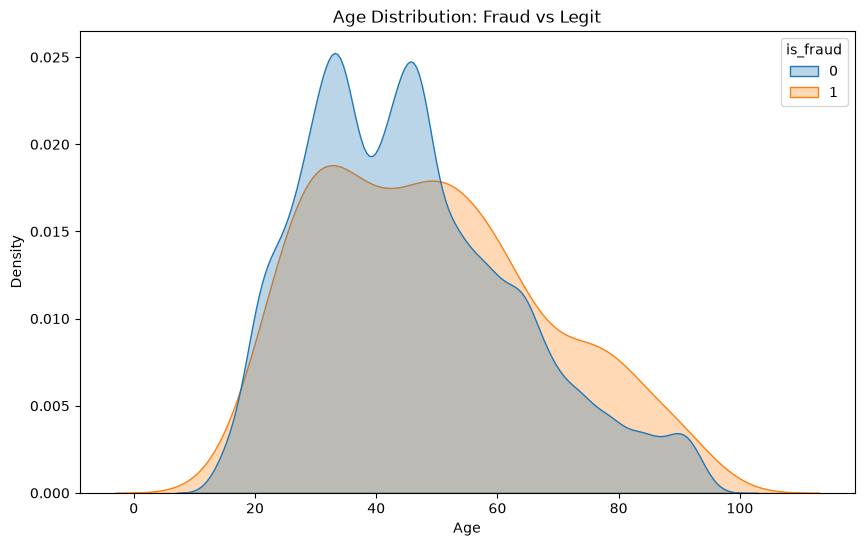

In [24]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=sample_df, x='age', hue='is_fraud', common_norm=False, fill=True, alpha=0.3)
plt.xlabel('Age')
plt.ylabel('Density')
plt.title('Age Distribution: Fraud vs Legit')
plt.savefig("charts/06_fraud_rate_by_age.png", bbox_inches='tight')
plt.show()

In [25]:
check_df = pd.read_csv("data_clean/fraud_sample_25k.csv")
print(check_df.shape)
check_df.head()

(25000, 27)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,hour,day_of_week,month,distance_km
0,2019-03-21 14:43:30,4874017206859125,"fraud_Schroeder, Hauck and Treutel",entertainment,188.30,Lauren,Williams,F,065 Jones Stravenue,Lake Oswego,...,b3a53d730ae500be3eba4cd871f00ea6,1332341010,45.565753,-122.849783,0,36,14,Thursday,3,21.639294
1,2020-07-20 00:56:06,4306630852918,"fraud_Langosh, Wintheiser and Hyatt",food_dining,101.63,Maureen,Garza,F,169 Edward Inlet,Saint Louis,...,6c3acede3c250c3b2244de443efc782c,1374281766,39.558931,-90.857192,0,60,0,Monday,7,110.454824
2,2020-06-13 00:08:01,3576431665303017,fraud_Schmeler Inc,misc_pos,237.33,Jessica,Ward,F,72269 Elizabeth Field Apt. 132,Phoenix,...,728a50cba8685293246dba5cee98e87a,1371082081,34.038290,-111.222946,0,38,0,Saturday,6,93.407442
3,2019-05-01 16:38:12,36078114201167,fraud_Kihn-Fritsch,food_dining,18.06,Christopher,Horn,M,956 Sanchez Highway,Mallie,...,8a2181a3c81dc8a7df968e668c216c2d,1335890292,38.089737,-82.131204,0,92,16,Wednesday,5,114.436270
4,2019-06-24 04:34:44,3500969075198072,fraud_Emard Inc,gas_transport,77.00,Kenneth,Sanchez,M,0110 Ashley Forest,Tekoa,...,e341488ee06ef30508a62118c3f1f4f1,1340512484,47.657307,-117.882492,0,20,4,Monday,6,76.898024


In [26]:
import os
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="mysql+pymysql",
    username="root",
    password=os.environ.get("MYSQL_PASSWORD"),
    host="localhost",
    port=3306,
    database="fraud_analysis"
)
engine = create_engine(url)